# 03 — Embeddings y clustering — Exploit.in

Genera embeddings semánticos de los 5.289 posts clasificados con `qwen3-embedding` (4096 dims),  
aplica UMAP + HDBSCAN y visualiza la estructura semántica del foro.

Los centroides de actor son **L2-normalizados** y compatibles con el espacio vectorial  
de los módulos ContiLeaks, BlackBasta y LockBit → comparativa cruzada directa.

Produce:
- `data/processed/exploitin_message_embeddings.npy` — matriz (N, 4096)
- `data/processed/exploitin_sample_with_embeddings.parquet` — posts + coords UMAP + cluster

## 0. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ollama
import umap
import hdbscan
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

PROCESSED      = Path('../data/processed')
SAMPLE_IN      = PROCESSED / 'exploitin_sample_classified.parquet'
PROFILES_IN    = PROCESSED / 'exploitin_user_profiles.json'
EMBEDDINGS_NPY = PROCESSED / 'exploitin_message_embeddings.npy'
SAMPLE_OUT     = PROCESSED / 'exploitin_sample_with_embeddings.parquet'

EMBED_MODEL = 'qwen3-embedding'
EMBED_DIMS  = 4096
BATCH_SIZE  = 16  # menor que otros módulos por mayor dimensionalidad

assert SAMPLE_IN.exists(),   f'Falta {SAMPLE_IN} — ejecuta notebook 02'
assert PROFILES_IN.exists(), f'Falta {PROFILES_IN} — ejecuta notebook 02'

sample = pd.read_parquet(SAMPLE_IN).reset_index(drop=True)
with open(PROFILES_IN, encoding='utf-8') as f:
    profiles = json.load(f)

print(f'Posts    : {len(sample):,}')
print(f'Actores  : {sample.username.nunique():,}')
print(f'Perfiles : {len(profiles)}')
print(f'Modelo   : {EMBED_MODEL}  ({EMBED_DIMS}D)')
print(f'\nCategorías:\n{sample.category.value_counts().to_string()}')

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Posts    : 5,289
Actores  : 1,081
Perfiles : 156
Modelo   : qwen3-embedding  (4096D)

Categorías:
category
community      1568
hacking         784
marketplace     775
programming     694
malware         658
spam            404
carding         291
unknown         115


## 1. Generación de embeddings

In [2]:
if EMBEDDINGS_NPY.exists():
    embeddings = np.load(EMBEDDINGS_NPY)
    assert len(embeddings) == len(sample), 'Embeddings y muestra desalineados — borra el .npy y re-ejecuta'
    print(f'Cargados desde caché: {embeddings.shape}')
else:
    texts = sample['content'].str.strip().tolist()
    embeddings = np.zeros((len(texts), EMBED_DIMS), dtype=np.float32)

    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc='Embeddings'):
        batch = [str(t)[:800] for t in texts[start:start + BATCH_SIZE]]
        resp  = ollama.embed(model=EMBED_MODEL, input=batch)
        for j, emb in enumerate(resp.embeddings):
            embeddings[start + j] = emb

    np.save(EMBEDDINGS_NPY, embeddings)
    print(f'Embeddings guardados: {embeddings.shape}  → {EMBEDDINGS_NPY}')

print(f'Dimensiones: {embeddings.shape[1]}D')

Embeddings: 100%|█████████████████████████████| 331/331 [04:08<00:00,  1.33it/s]

Embeddings guardados: (5289, 4096)  → ../data/processed/exploitin_message_embeddings.npy
Dimensiones: 4096D


## 2. Centroides por actor

Media L2-normalizada de todos los embeddings de cada usuario.  
Solo actores con ≥ 8 posts para centroides robustos.

In [3]:
MIN_POSTS = 8
sample_indexed = sample.copy()
sample_indexed['emb_idx'] = range(len(sample_indexed))

actor_centroids = {}
for actor, group in sample_indexed.groupby('username'):
    if len(group) < MIN_POSTS:
        continue
    vecs = embeddings[group['emb_idx'].tolist()]
    c = vecs.mean(axis=0)
    c /= np.linalg.norm(c)   # L2-normalización
    actor_centroids[actor] = c

actor_names  = list(actor_centroids.keys())
actor_matrix = np.array([actor_centroids[a] for a in actor_names])

print(f'Actores con centroide (≥{MIN_POSTS} posts): {len(actor_names)}')
print(f'Matriz de centroides: {actor_matrix.shape}')

Actores con centroide (≥8 posts): 156
Matriz de centroides: (156, 4096)


## 3. UMAP — reducción a 2D

In [4]:
print('Ajustando UMAP sobre posts...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
msg_2d   = reducer.fit_transform(embeddings)
actor_2d = reducer.transform(actor_matrix)

sample['umap_x'] = msg_2d[:, 0]
sample['umap_y'] = msg_2d[:, 1]

print(f'Posts en 2D  : {msg_2d.shape}')
print(f'Actores en 2D: {actor_2d.shape}')

/home/drjekyll/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Ajustando UMAP sobre posts...
Posts en 2D  : (5289, 2)
Actores en 2D: (156, 2)


## 4. HDBSCAN — clustering

In [5]:
# Clustering de posts
clusterer_posts = hdbscan.HDBSCAN(min_cluster_size=40, min_samples=5)
post_clusters = clusterer_posts.fit_predict(msg_2d)
sample['cluster'] = post_clusters

n_clusters = (np.unique(post_clusters) >= 0).sum()
print(f'Clusters de posts   : {n_clusters}')
print(f'Ruido (cluster -1)  : {(post_clusters == -1).sum():,} posts')

# Clustering de actores
clusterer_actors = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=2, metric='euclidean')
actor_clusters = clusterer_actors.fit_predict(actor_2d)

n_actor_cl = len(set(actor_clusters)) - (1 if -1 in actor_clusters else 0)
n_noise_ac = (actor_clusters == -1).sum()
print(f'\nClusters de actores : {n_actor_cl}')
print(f'Actores sin cluster : {n_noise_ac}')
print()
for cl in sorted(set(actor_clusters)):
    members = [actor_names[i] for i, c in enumerate(actor_clusters) if c == cl]
    label = 'ruido' if cl == -1 else f'cluster {cl}'
    print(f'  {label:<12}: {members[:8]}{" ..." if len(members)>8 else ""}')

Clusters de posts   : 32
Ruido (cluster -1)  : 1,779 posts

Clusters de actores : 12
Actores sin cluster : 28

  ruido       : ['Exper1menT', 'Hytex', 'Imper1um', 'Kallisto', 'Ni0x', 'Nilson', 'Noctambulaar', 'Nucleus'] ...
  cluster 0   : ['3l33t', 'CkaZu', 'Ego1st', 'Marduk', 'Robin Gud', 'Stalin', 'hellwood', 'hsi']
  cluster 1   : ['Obivankor', 'Richy', 'Transporter', 'debug', 'deric', 'krot', 'parik', 'starw']
  cluster 2   : ['Deret', 'L0ki', 'eraflame']
  cluster 3   : ['Admin CI', 'Azazel', 'GOoDok', 'smilesxxx', 'takahashi']
  cluster 4   : ['()G3R', 'Romisnet', 'Sta&#33;&#036;', 'Toredo', '_Master-', 'sclan']
  cluster 5   : ['Ar3s', 'Ghost Bear', 'ultra']
  cluster 6   : ['D15', 'DeaDMonaX', 'DeadStudent', 'Trash', 'pahomoff', 'slavarion']
  cluster 7   : ['Caponex', 'rrr111', 'vesselii', 'zybc']
  cluster 8   : ['Out', 'Plaza', 'plague', 'мани']
  cluster 9   : ['Djeike 2.0', 'JFK', 'OniX', 'USD', 'Varchun', 'bu&#33;ik', 'lift', 'm4rrow'] ...
  cluster 10  : ['Mаil2k', 'mad

## 5. Visualizaciones

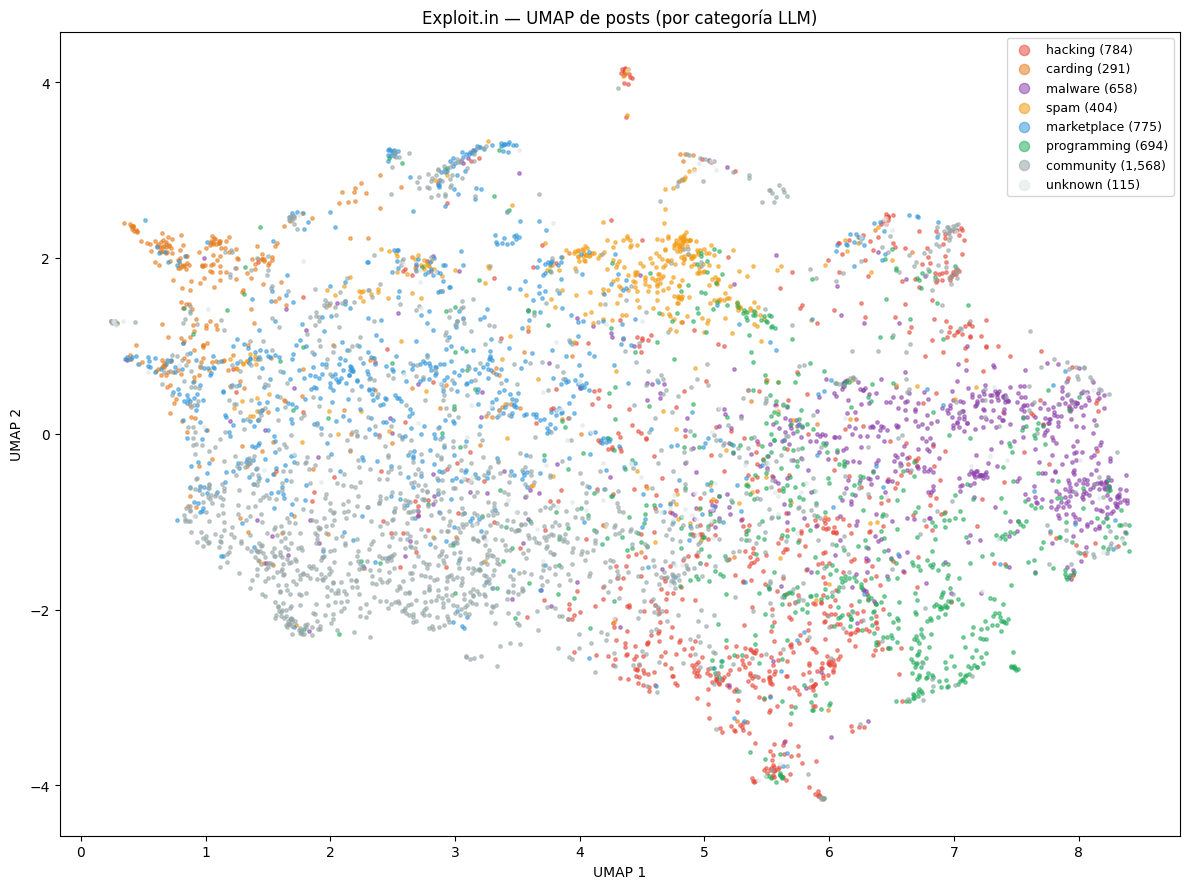

In [6]:
# Scatter de posts por categoría
cat_colors = {
    'hacking':     '#e74c3c',
    'carding':     '#e67e22',
    'malware':     '#8e44ad',
    'spam':        '#f39c12',
    'marketplace': '#3498db',
    'programming': '#27ae60',
    'community':   '#95a5a6',
    'unknown':     '#dfe6e9',
}

fig, ax = plt.subplots(figsize=(12, 9))
for cat, color in cat_colors.items():
    mask = sample['category'] == cat
    if mask.sum() == 0:
        continue
    ax.scatter(msg_2d[mask, 0], msg_2d[mask, 1],
               c=color, s=6, alpha=0.55, label=f'{cat} ({mask.sum():,})', rasterized=True)

ax.set_title('Exploit.in — UMAP de posts (por categoría LLM)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3, fontsize=9, loc='best')
plt.tight_layout()
plt.show()

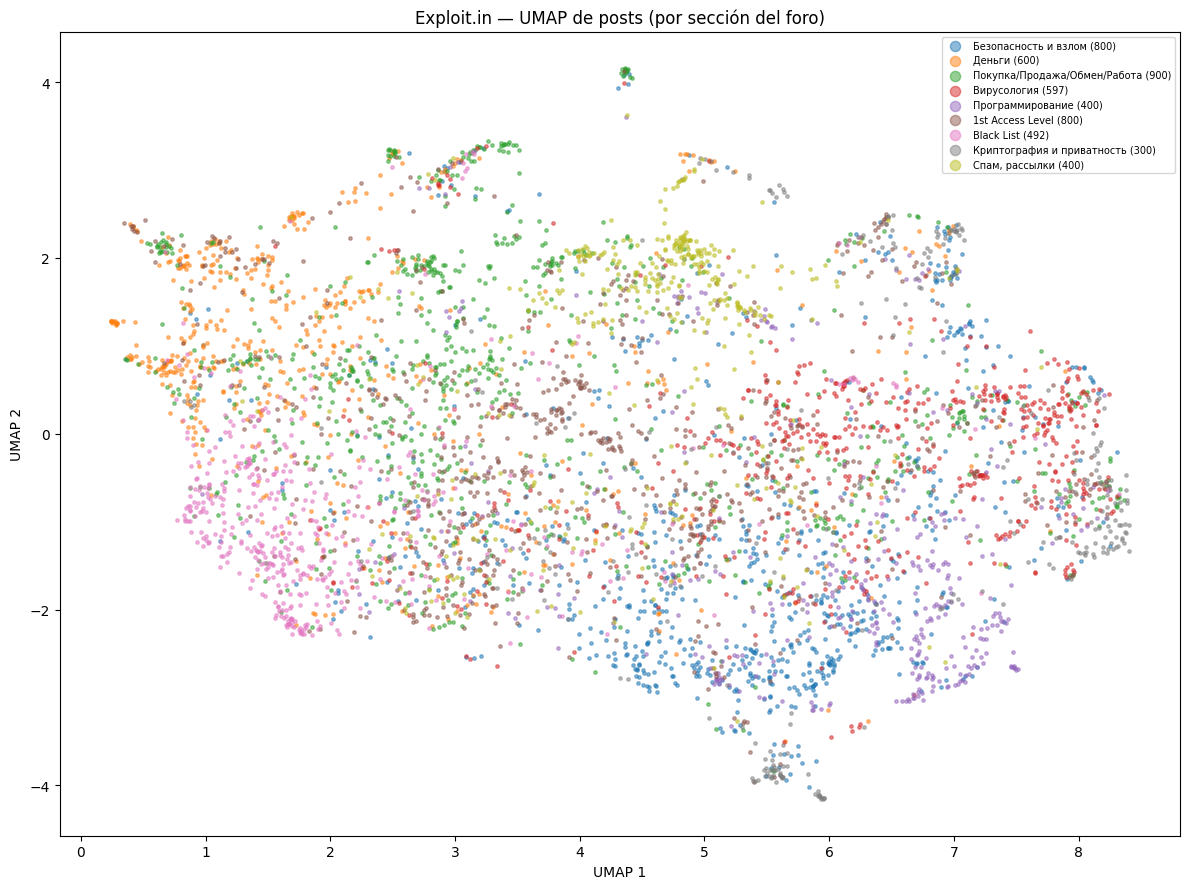

In [7]:
# Scatter de posts por sección del foro
sections = sample['forum_name'].unique()
palette  = cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, 9))
for i, sec in enumerate(sections):
    mask = sample['forum_name'] == sec
    ax.scatter(msg_2d[mask, 0], msg_2d[mask, 1],
               c=[palette[i % len(palette)]], s=6, alpha=0.5,
               label=f'{sec[:30]} ({mask.sum():,})', rasterized=True)

ax.set_title('Exploit.in — UMAP de posts (por sección del foro)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3, fontsize=7, loc='best')
plt.tight_layout()
plt.show()

/tmp/ipykernel_133109/770599892.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],


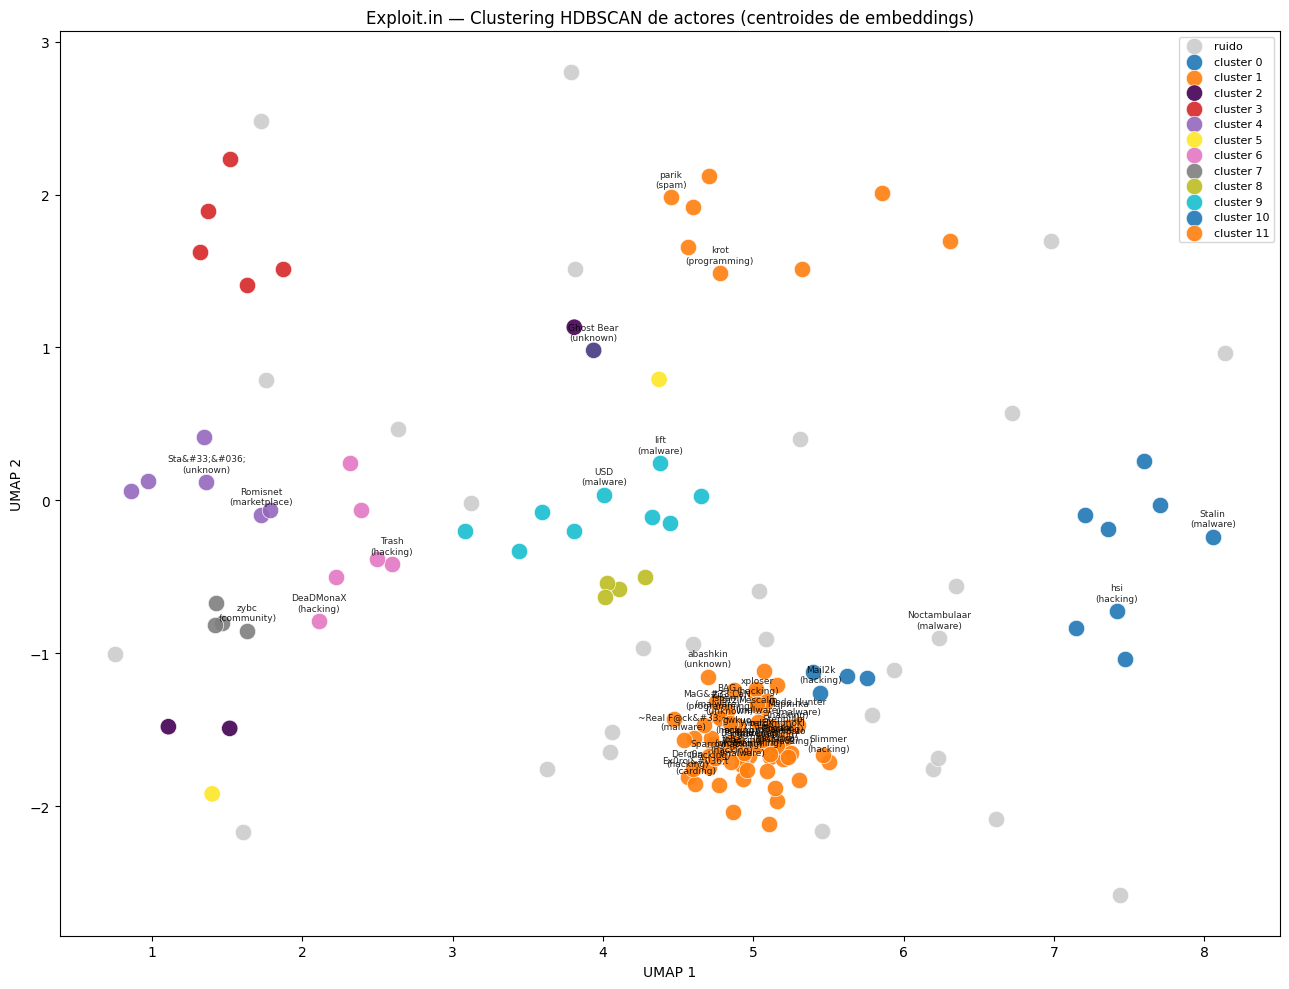

Cluster HDBSCAN × Especialidad LLM:
specialty  carding  community  hacking  malware  marketplace  programming  \
cluster                                                                     
-1               3          1        7        7            1            6   
 0               0          0        2        5            0            0   
 1               1          0        0        0            0            2   
 2               1          1        0        0            0            0   
 3               3          1        0        0            0            0   
 4               1          1        0        1            1            0   
 5               0          1        0        0            0            1   
 6               0          2        3        0            0            0   
 7               0          1        0        0            1            0   
 8               1          1        0        2            0            0   
 9               1          1        4  

In [8]:
# Scatter de actores coloreados por cluster + rol LLM
fig, ax = plt.subplots(figsize=(13, 10))

for cl in sorted(set(actor_clusters)):
    mask  = actor_clusters == cl
    color = '#cccccc' if cl == -1 else palette[cl % len(palette)]
    label = 'ruido' if cl == -1 else f'cluster {cl}'
    ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],
               c=color, s=140, alpha=0.9, label=label,
               edgecolors='white', linewidths=0.5, zorder=3)

# Etiquetar solo actores con alta confianza o más posts
top_actors = sample.groupby('username').size().nlargest(40).index
for i, name in enumerate(actor_names):
    if name in top_actors:
        role = profiles.get(name, {}).get('specialty', '?')
        ax.annotate(f'{name}\n({role})', (actor_2d[i, 0], actor_2d[i, 1]),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points', alpha=0.85)

ax.set_title('Exploit.in — Clustering HDBSCAN de actores (centroides de embeddings)')
ax.legend(fontsize=8)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

# Comparativa cluster vs especialidad LLM
actor_df = pd.DataFrame({
    'actor':     actor_names,
    'cluster':   actor_clusters,
    'umap_x':    actor_2d[:, 0],
    'umap_y':    actor_2d[:, 1],
    'specialty': [profiles.get(a, {}).get('specialty', '?') for a in actor_names],
    'role':      [profiles.get(a, {}).get('role', '?') for a in actor_names],
    'confidence':[profiles.get(a, {}).get('confidence', 'low') for a in actor_names],
})

print('Cluster HDBSCAN × Especialidad LLM:')
print(pd.crosstab(actor_df['cluster'], actor_df['specialty']))

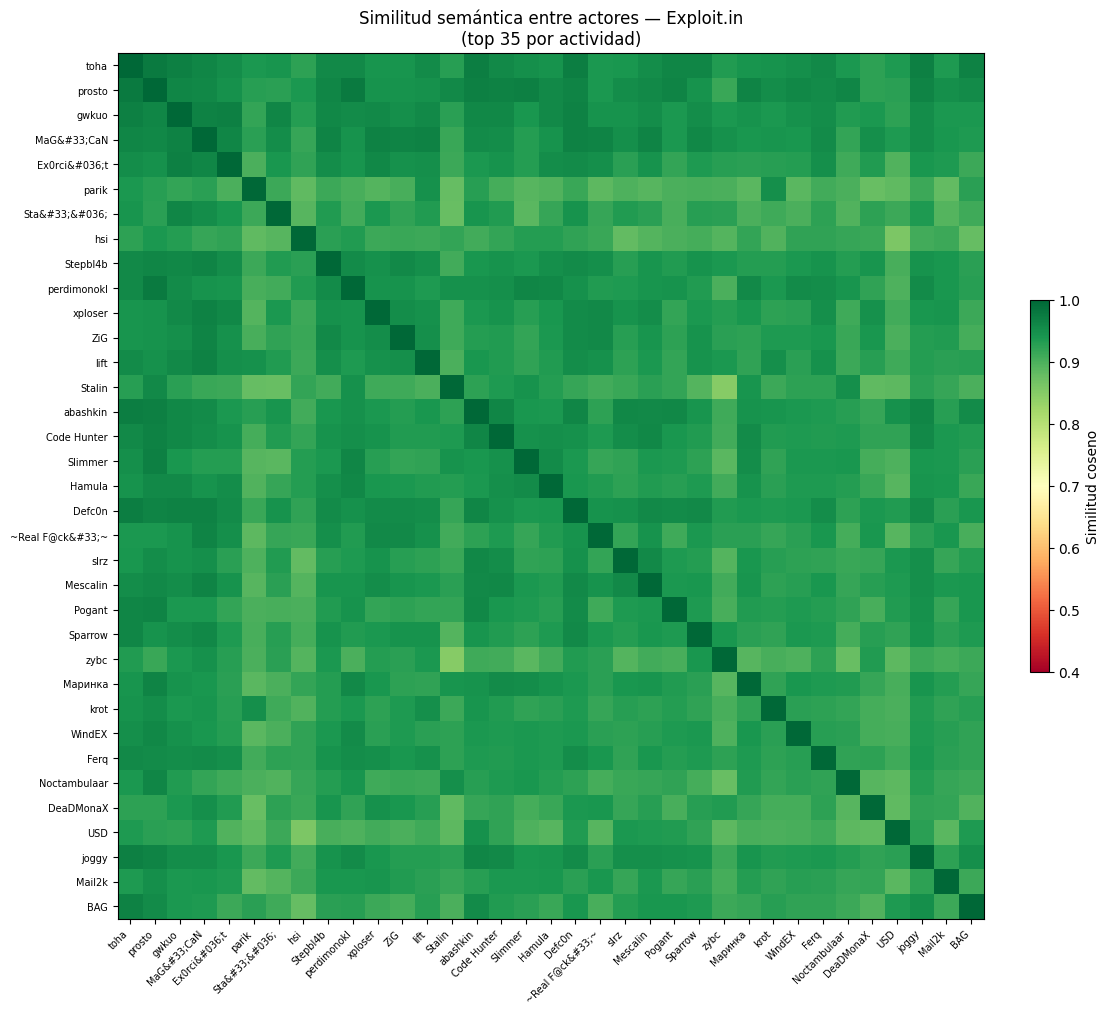

Top 5 pares con mayor similitud semántica:
  toha                [hacking     ] ↔ prosto              [hacking     ]  sim=0.976
  prosto              [hacking     ] ↔ perdimonokl         [hacking     ]  sim=0.974
  toha                [hacking     ] ↔ Defc0n              [hacking     ]  sim=0.971
  toha                [hacking     ] ↔ abashkin            [unknown     ]  sim=0.970
  prosto              [hacking     ] ↔ Slimmer             [hacking     ]  sim=0.969


In [9]:
# Heatmap de similitud coseno — top 35 actores por posts
top35 = sample.groupby('username').size().nlargest(35).index.tolist()
top35 = [a for a in top35 if a in actor_centroids]

mat35 = np.array([actor_centroids[a] for a in top35])
sim35 = cosine_similarity(mat35)

n = len(top35)
fig_sz = max(9, n * 0.32)
fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
im = ax.imshow(sim35, cmap='RdYlGn', vmin=0.4, vmax=1.0)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(top35, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(top35, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.02, label='Similitud coseno')
ax.set_title('Similitud semántica entre actores — Exploit.in\n(top 35 por actividad)')
plt.tight_layout()
plt.show()

# Top 5 pares más similares
np.fill_diagonal(sim35, -1)
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((sim35[i,j], top35[i], top35[j]))
pairs.sort(reverse=True)
print('Top 5 pares con mayor similitud semántica:')
for sim, a, b in pairs[:5]:
    ra = profiles.get(a, {}).get('specialty', '?')
    rb = profiles.get(b, {}).get('specialty', '?')
    print(f'  {a:20s}[{ra:12s}] ↔ {b:20s}[{rb:12s}]  sim={sim:.3f}')

## 6. Guardar

In [10]:
sample.to_parquet(SAMPLE_OUT, index=False)

print(f'Embeddings      → {EMBEDDINGS_NPY}  {embeddings.shape}')
print(f'Posts + UMAP    → {SAMPLE_OUT}')
print(f'\nResumen:')
print(f'  Posts embebidos    : {len(sample):,}')
print(f'  Dimensiones        : {embeddings.shape[1]}D  ({EMBED_MODEL})')
print(f'  Clusters de posts  : {n_clusters}')
print(f'  Actores analizados : {len(actor_names)}')
print(f'  Clusters de actores: {n_actor_cl}')
print()
print('Archivos listos para el notebook comparativo:')
print(f'  exploitin_message_embeddings.npy')
print(f'  exploitin_sample_with_embeddings.parquet')
print(f'  exploitin_user_profiles.json')

Embeddings      → ../data/processed/exploitin_message_embeddings.npy  (5289, 4096)
Posts + UMAP    → ../data/processed/exploitin_sample_with_embeddings.parquet

Resumen:
  Posts embebidos    : 5,289
  Dimensiones        : 4096D  (qwen3-embedding)
  Clusters de posts  : 32
  Actores analizados : 156
  Clusters de actores: 12

Archivos listos para el notebook comparativo:
  exploitin_message_embeddings.npy
  exploitin_sample_with_embeddings.parquet
  exploitin_user_profiles.json
